# Genome-resolved metatranscriptomics analysis for Phaeocystis globosa
In this notebook, we'll analyze the patterns in reads mapped to the Phaglo1 genome, sourced from [this study](https://www.researchsquare.com/article/rs-6767494/v1). The [reads have been mapped](../rules/phaglo1_mapping.smk) to the transcript models using salmon with decoys consisting of organellar sequences and the masked genome, the resulting reads were aggregated to the gene level and [annotations were combined](../rules/phaglo1_annotation.smk) at the gene level.

Now, we'll extract overall Phaeocystis read counts over the diel cycle and normalized expression for genes involved in pathways of interest.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import requests
import numpy as np
import seaborn as sns
import time
from goatools.obo_parser import GODag
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list
from matplotlib.ticker import FuncFormatter
from matplotlib.dates import date2num, HourLocator, DateFormatter
import statsmodels.api as sm
import matplotlib.dates as mdates

## Data preparation

In [3]:
# Read in the environmental data
env_data = pd.read_csv('../data/samples_env.csv')
# Rename station column
env_data.rename(columns={'Station': 'sample'}, inplace=True)
env_data["Date"] = pd.to_datetime(env_data["Date"])

env_data.head()

,sample,StationPrefix,StationSuffix,Latitude,Longitude,Date,day_moment,day_length,Temperature,Salinity,...,Fluorescence,NH4,NO2,NO3,NOX,PO4,Si,TEP,sea_surface_height_above_sea_level,surface_baroclinic_sea_water_velocity
0,51_1,51,1,51.531661,3.182804,2023-04-18 11:11:00,Day,14.033333,9.9259,32.513,...,2.001848,3.08,0.16,6.96,7.12,0.10,7.24,65.846667,1.817039,0.737313
1,51_2,51,2,51.533392,3.184085,2023-04-18 12:05:00,Day,14.033333,9.9105,32.683,...,NaN,3.45,0.15,6.19,6.34,0.14,7.06,167.438667,2.129479,0.933577
2,51_3,51,3,51.532763,3.185113,2023-04-18 13:08:00,Day,14.033333,9.9231,32.661,...,1.472718,3.53,0.15,6.13,6.28,0.12,7.13,210.709333,1.852063,0.844862
3,51_4,51,4,51.533244,3.184346,2023-04-18 14:05:00,Day,14.033333,9.9013,32.703,...,1.423711,NaN,NaN,NaN,NaN,NaN,NaN,255.861333,1.210772,0.645538
4,51_5,51,5,51.533104,3.183575,2023-04-18 15:07:00,Day,14.033333,9.9336,32.590,...,1.315579,4.18,0.15,6.54,6.69,0.15,7.53,223.878667,0.336479,0.489504


In [4]:
phaeo_reads = pd.read_csv('../data/phaglo1_mapping/gene_expression/gene_numreads.tsv', sep='\t', index_col=0)

phaeo_reads.head()

,51_1,51_2,51_3,51_4,51_5,51_6,51_7,51_8,51_9,51_10,...,130_16,130_17,130_18,130_19,130_20,130_21,130_22,130_23,130_24,130_25
gene_id,,,,,,,,,,,,,,,,,,,,,
gene_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,19.275,0.0,0.0,33.0,0.0,0.0,15.044
gene_10,49.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,12.0,135.0,218.000,118.0,54.0,133.0,92.0,103.0,97.000
gene_100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,21.0,19.000
gene_1000,290.0,227.0,78.0,0.0,0.0,0.0,55.0,142.0,0.0,11.0,...,92.0,280.0,257.0,526.005,178.0,245.0,151.0,420.0,357.0,678.234
gene_10000,88.0,84.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,12.0,0.0,48.000,36.0,50.0,29.0,68.0,16.0,73.000


In [5]:
# How many genes are there?
print(f'Total number of genes in Phaglo1: {phaeo_reads.shape[0]}')

Total number of genes in Phaglo1: 32139


In [95]:
phaeo_tpm = pd.read_csv('../data/phaglo1_mapping/gene_expression/gene_tpm.tsv', sep='\t', index_col=0)

phaeo_tpm.head()

,51_1,51_2,51_3,51_4,51_5,51_6,51_7,51_8,51_9,51_10,...,130_16,130_17,130_18,130_19,130_20,130_21,130_22,130_23,130_24,130_25
gene_id,,,,,,,,,,,,,,,,,,,,,
gene_1,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,2.989903,0.000000,0.000000,14.041258,0.000000,0.000000,2.819531
gene_10,20.486173,8.811151,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,1.881031,14.698474,16.670995,10.938011,6.594544,27.461950,9.731935,11.472023,8.990345
gene_100,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.094904,0.850071
gene_1000,42.235906,50.610992,24.31767,0.0,0.0,0.0,66.382053,79.964458,0.0,5.720297,...,21.022341,16.015028,10.981953,14.433991,6.219126,11.672032,10.822299,14.660555,13.286945,21.815397
gene_10000,34.065645,47.529602,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,1.747604,0.000000,3.219307,3.030902,5.704782,5.469912,6.331883,1.567233,5.937556


In [96]:
annotation = pd.read_csv('../data/phaglo1_mapping/annotation/gene_functions.tsv', sep='\t', index_col=0)

annotation.head()

,n_proteins,EC,KEGG_def,KEGG_pathway,GO,GO_name,GO_type,IPR,KOG,KOG_desc,CAZy,CAZy_desc,signalp
gene_id,,,,,,,,,,,,,
gene_1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
gene_10,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
gene_100,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
gene_1000,2,NaN,NaN,NaN,NaN,NaN,NaN,IPR005069;IPR029044,NaN,NaN,NaN,NaN,False
gene_10000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [97]:
data_merged.head()

,gene_id,sample,TPM,sample_name,norm_factor,TPL
0,gene_1,51_1,0.000000,51_1,29.417324,0.000000
1,gene_10,51_1,20.486173,51_1,29.417324,602.648394
2,gene_100,51_1,0.000000,51_1,29.417324,0.000000
3,gene_1000,51_1,42.235906,51_1,29.417324,1242.467343
4,gene_10000,51_1,34.065645,51_1,29.417324,1002.120126


In [98]:
# Calculate TPL per sample
ERCC_normalisation = pd.read_csv('../data/ERCC92/ERCC_normalisation.csv')

# Melt the phaeocystis expression data to long format
data_melted = phaeo_tpm.reset_index().melt(id_vars='gene_id', var_name='sample', value_name='TPM')

# Merge with normalisation factors
data_merged = data_melted.merge(ERCC_normalisation, left_on='sample', right_on='sample_name', how='left')

# Calculate TPL
data_merged['TPL'] = data_merged['TPM'] * data_merged['norm_factor']

# Transform back to wide format
transcripts_per_liter = data_merged.pivot(index='gene_id', columns='sample', values='TPL')

## Exploratory analysis

In [99]:
# Combine numreads per sample, sum across rows
phaeo_numread_sums = phaeo_reads.sum(axis=0).reset_index()

# Name columns
phaeo_numread_sums.columns = ['sample', 'numreads']
# Add environmental data to numread sums
phaeo_numread_sums = phaeo_numread_sums.merge(env_data, on='sample', how='left')

phaeo_numread_sums.head()

,sample,numreads,StationPrefix,StationSuffix,Latitude,Longitude,Date,day_moment,day_length,Temperature,...,Fluorescence,NH4,NO2,NO3,NOX,PO4,Si,TEP,sea_surface_height_above_sea_level,surface_baroclinic_sea_water_velocity
0,51_1,2762112.991,51,1,51.531661,3.182804,2023-04-18 11:11:00,Day,14.033333,9.9259,...,2.001848,3.08,0.16,6.96,7.12,0.10,7.24,65.846667,1.817039,0.737313
1,51_2,1915204.997,51,2,51.533392,3.184085,2023-04-18 12:05:00,Day,14.033333,9.9105,...,NaN,3.45,0.15,6.19,6.34,0.14,7.06,167.438667,2.129479,0.933577
2,51_3,1331904.998,51,3,51.532763,3.185113,2023-04-18 13:08:00,Day,14.033333,9.9231,...,1.472718,3.53,0.15,6.13,6.28,0.12,7.13,210.709333,1.852063,0.844862
3,51_4,382776.001,51,4,51.533244,3.184346,2023-04-18 14:05:00,Day,14.033333,9.9013,...,1.423711,NaN,NaN,NaN,NaN,NaN,NaN,255.861333,1.210772,0.645538
4,51_5,73465.002,51,5,51.533104,3.183575,2023-04-18 15:07:00,Day,14.033333,9.9336,...,1.315579,4.18,0.15,6.54,6.69,0.15,7.53,223.878667,0.336479,0.489504


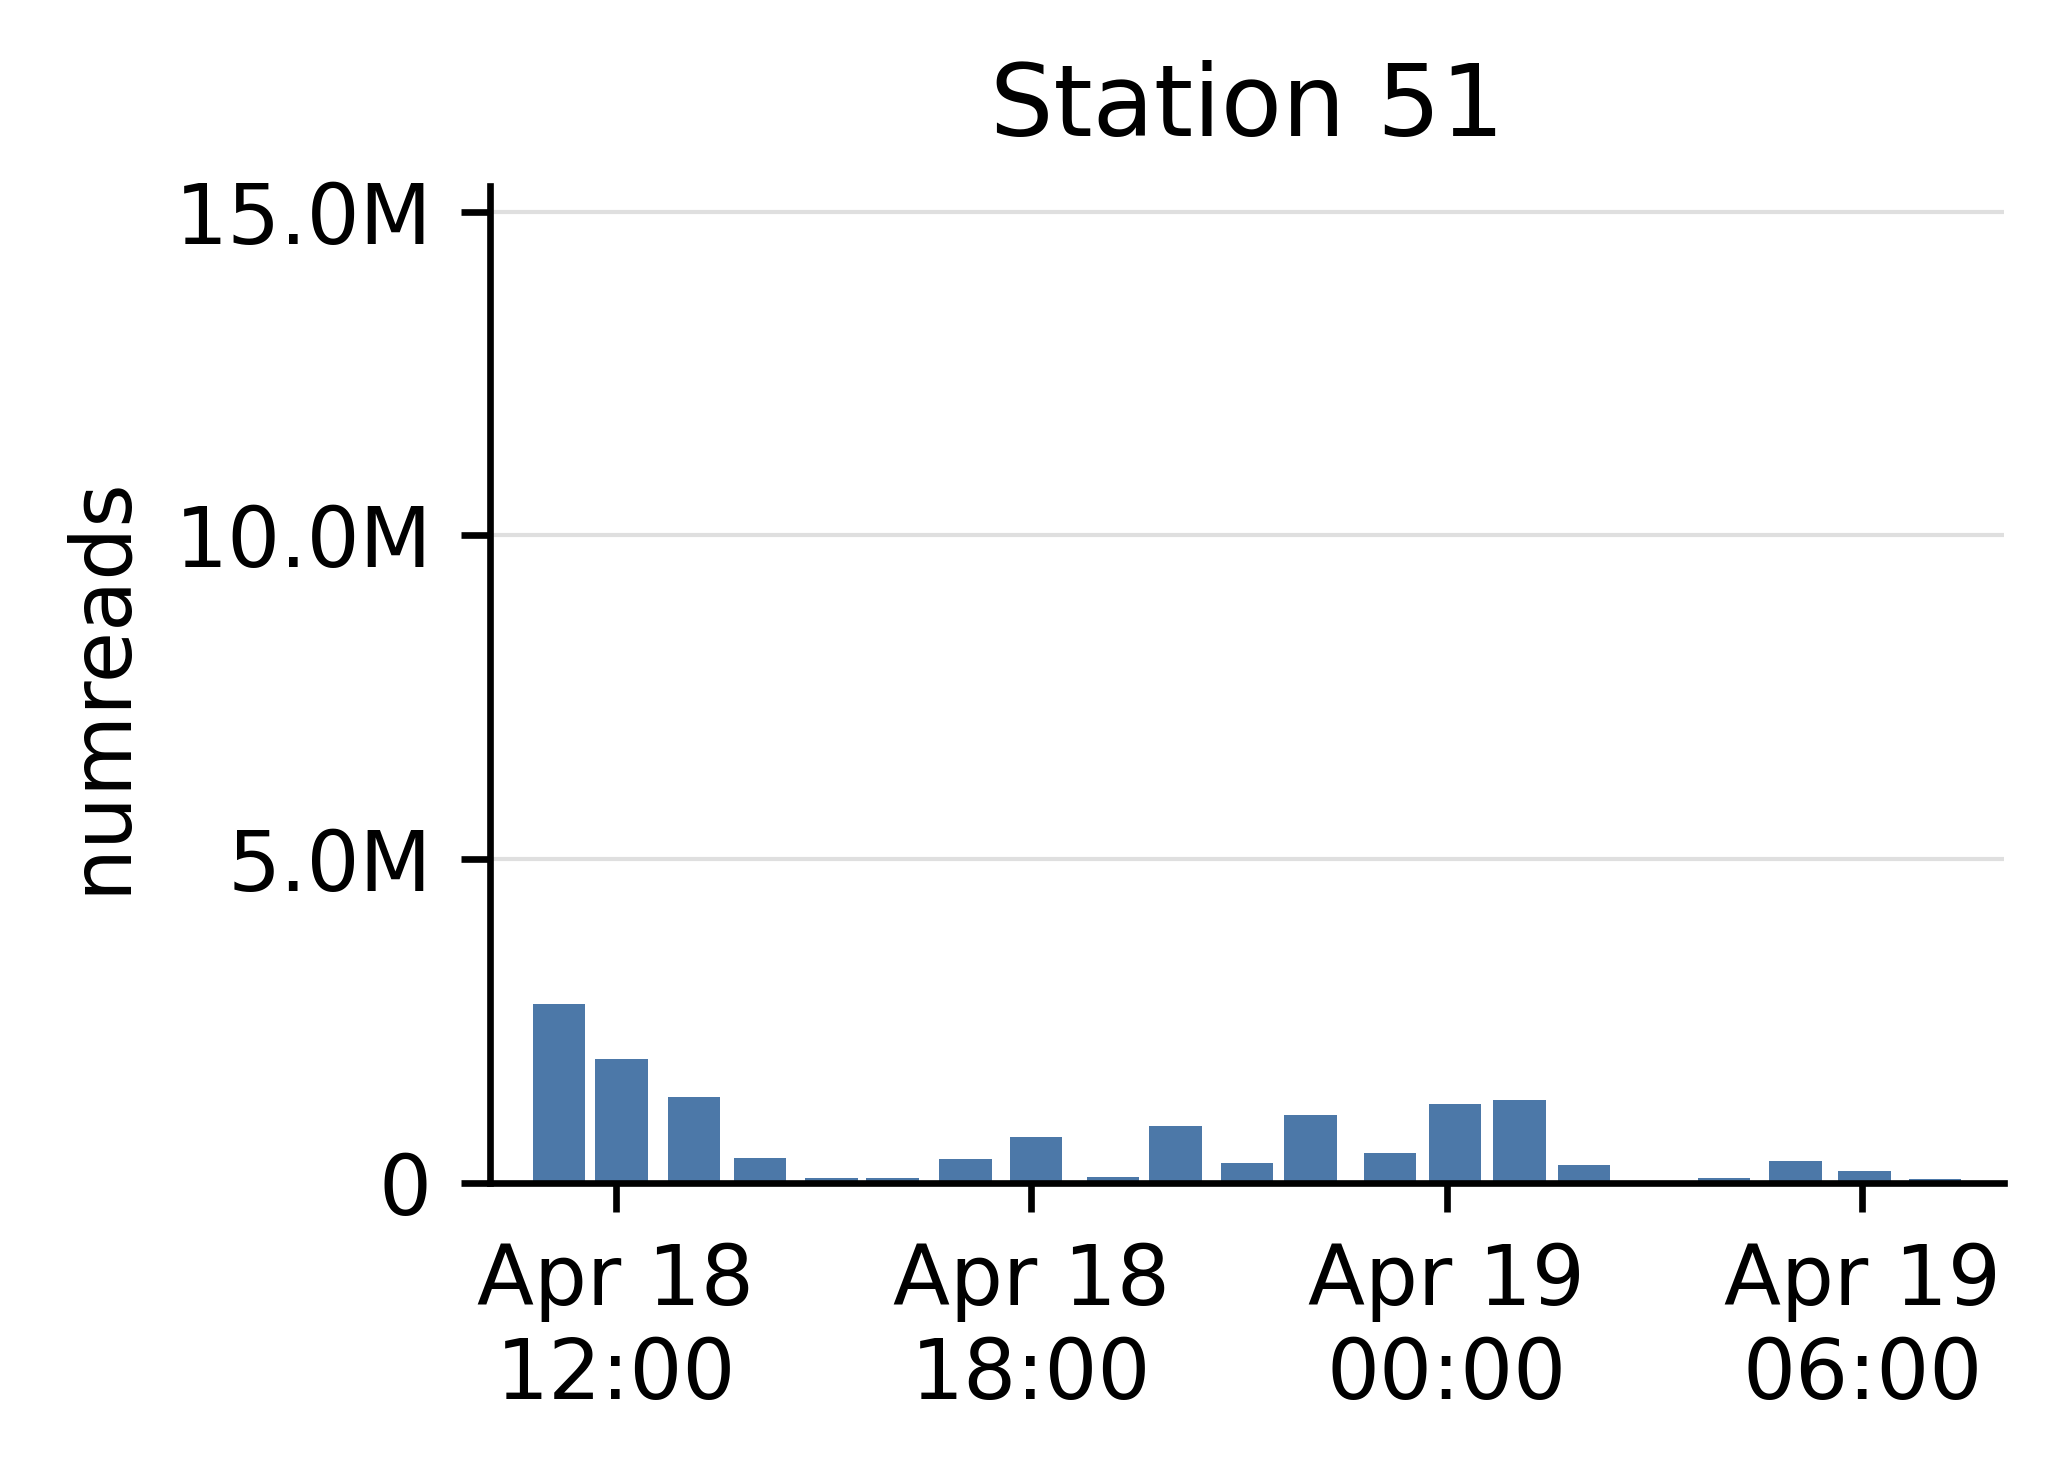

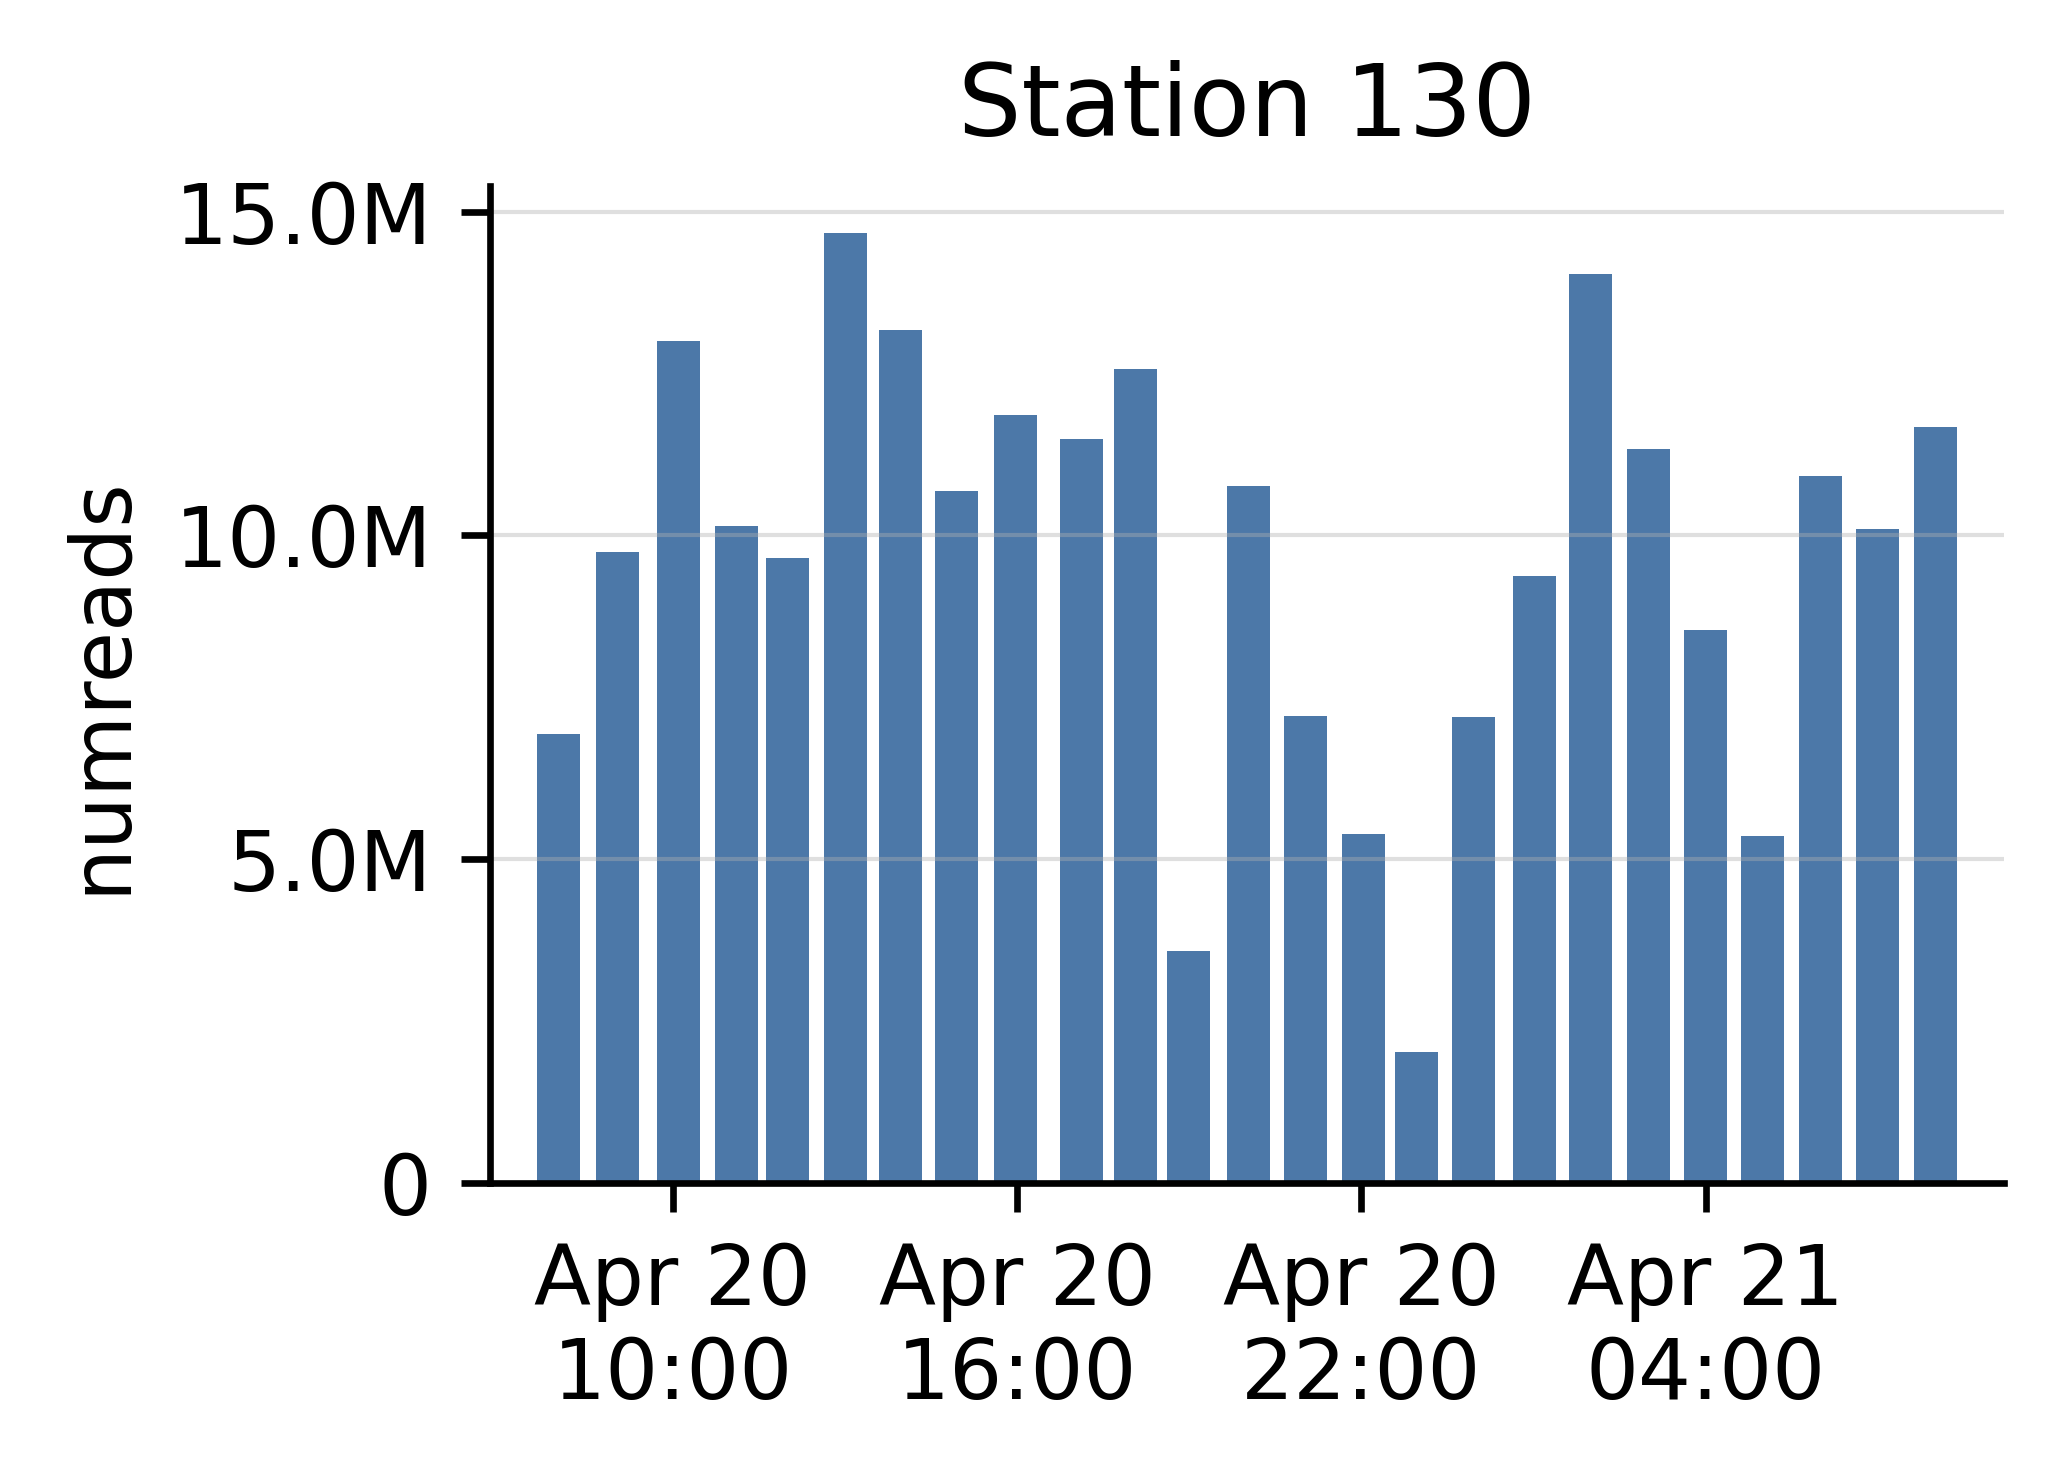

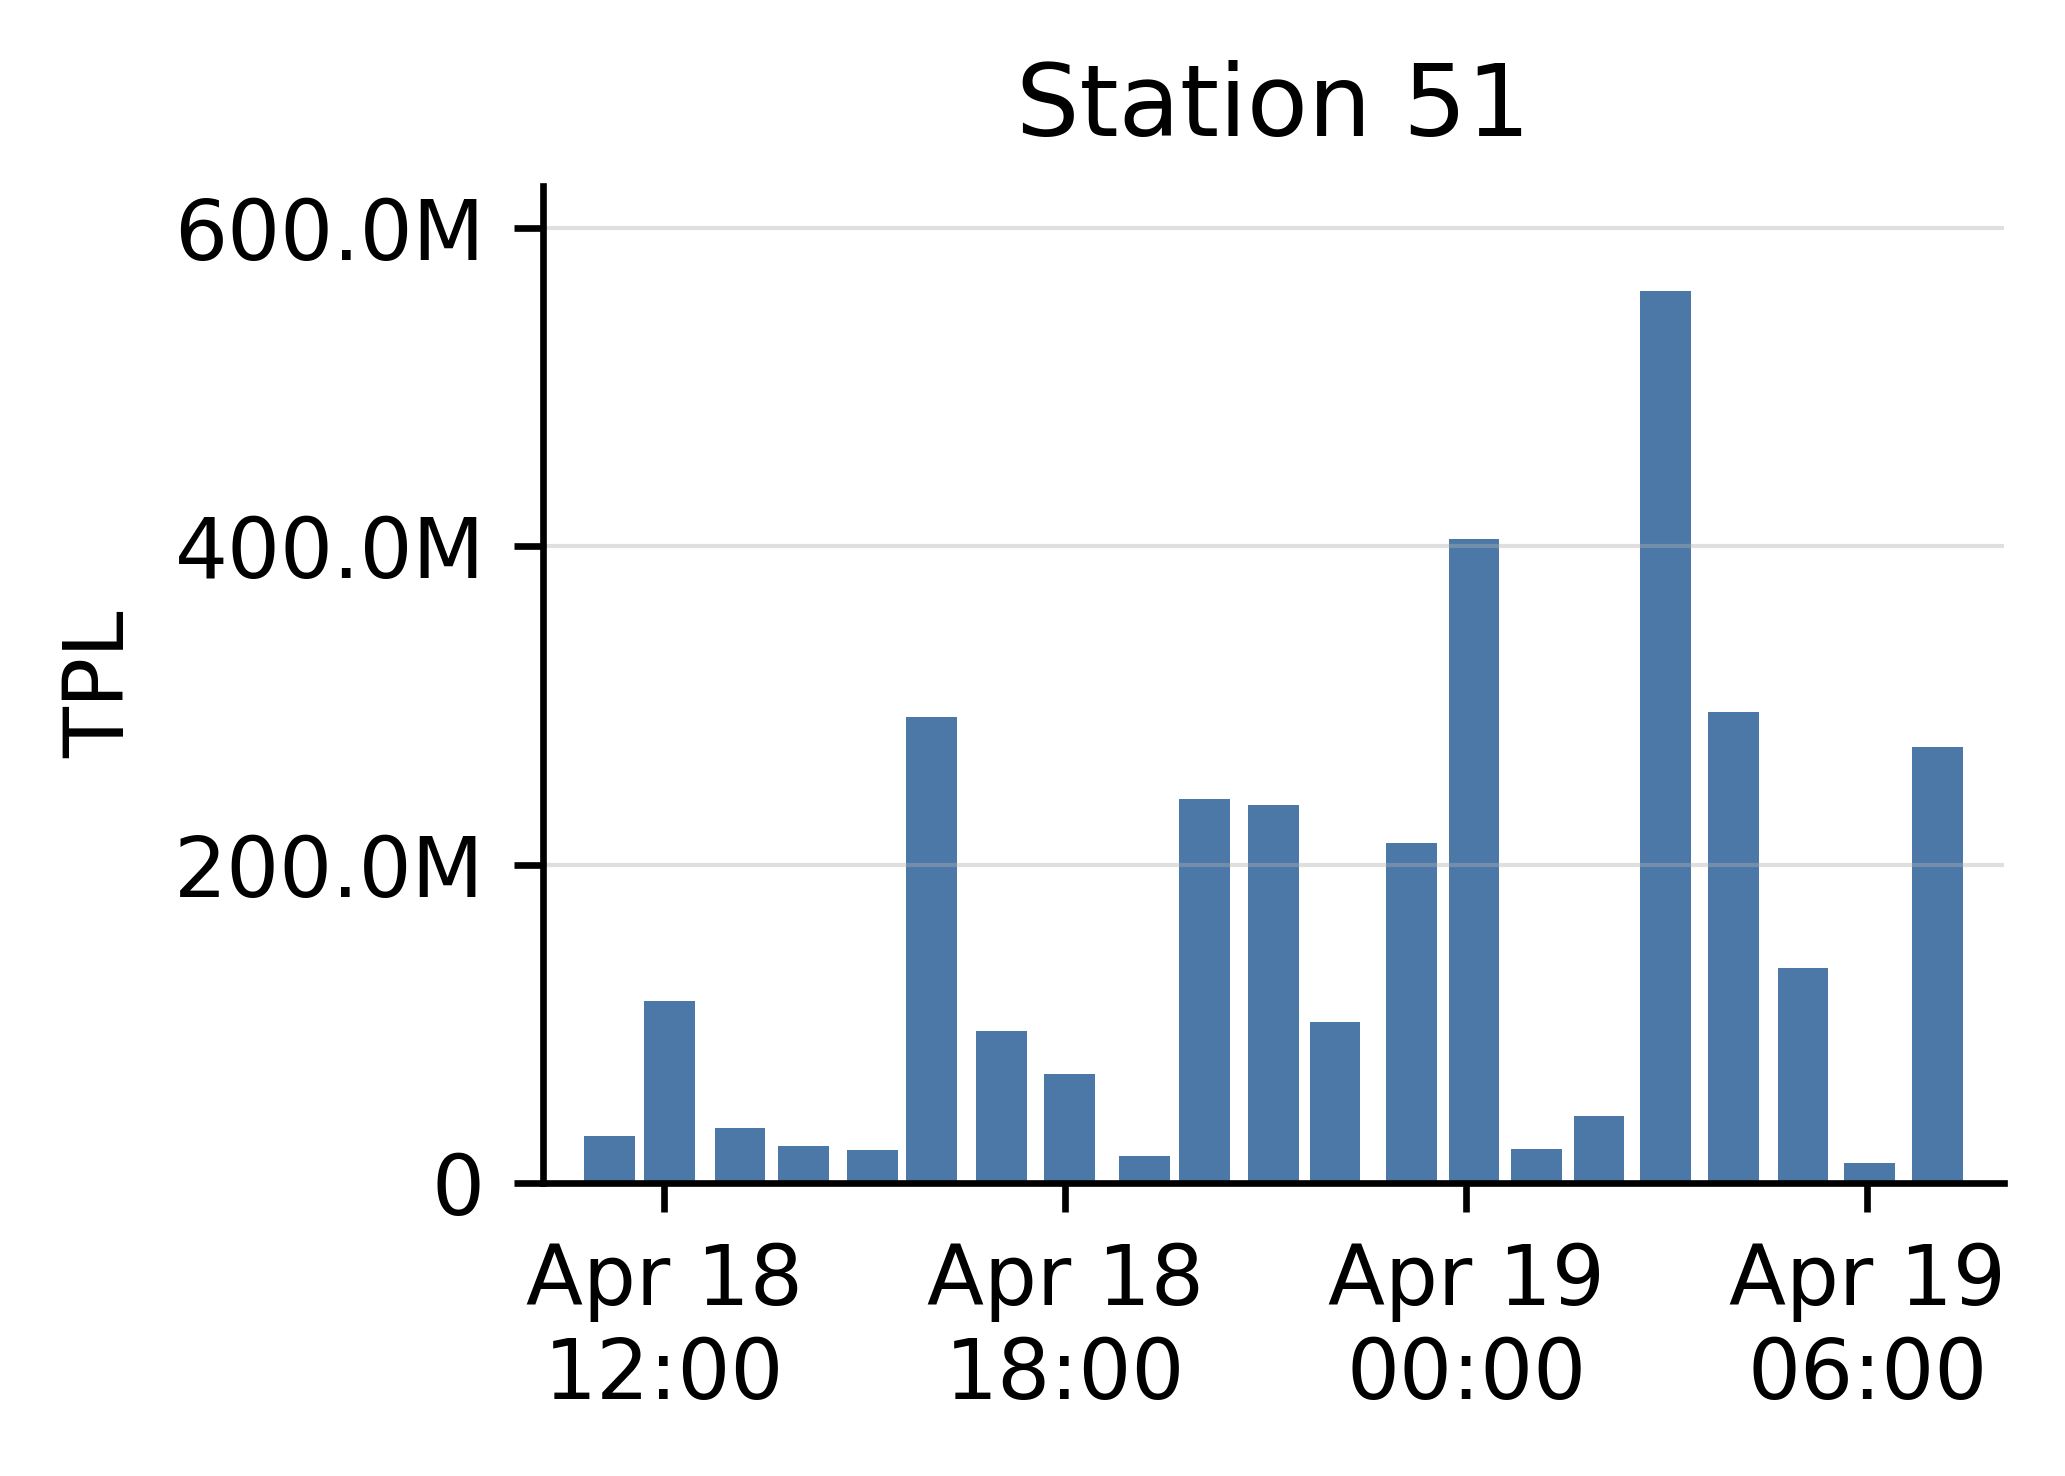

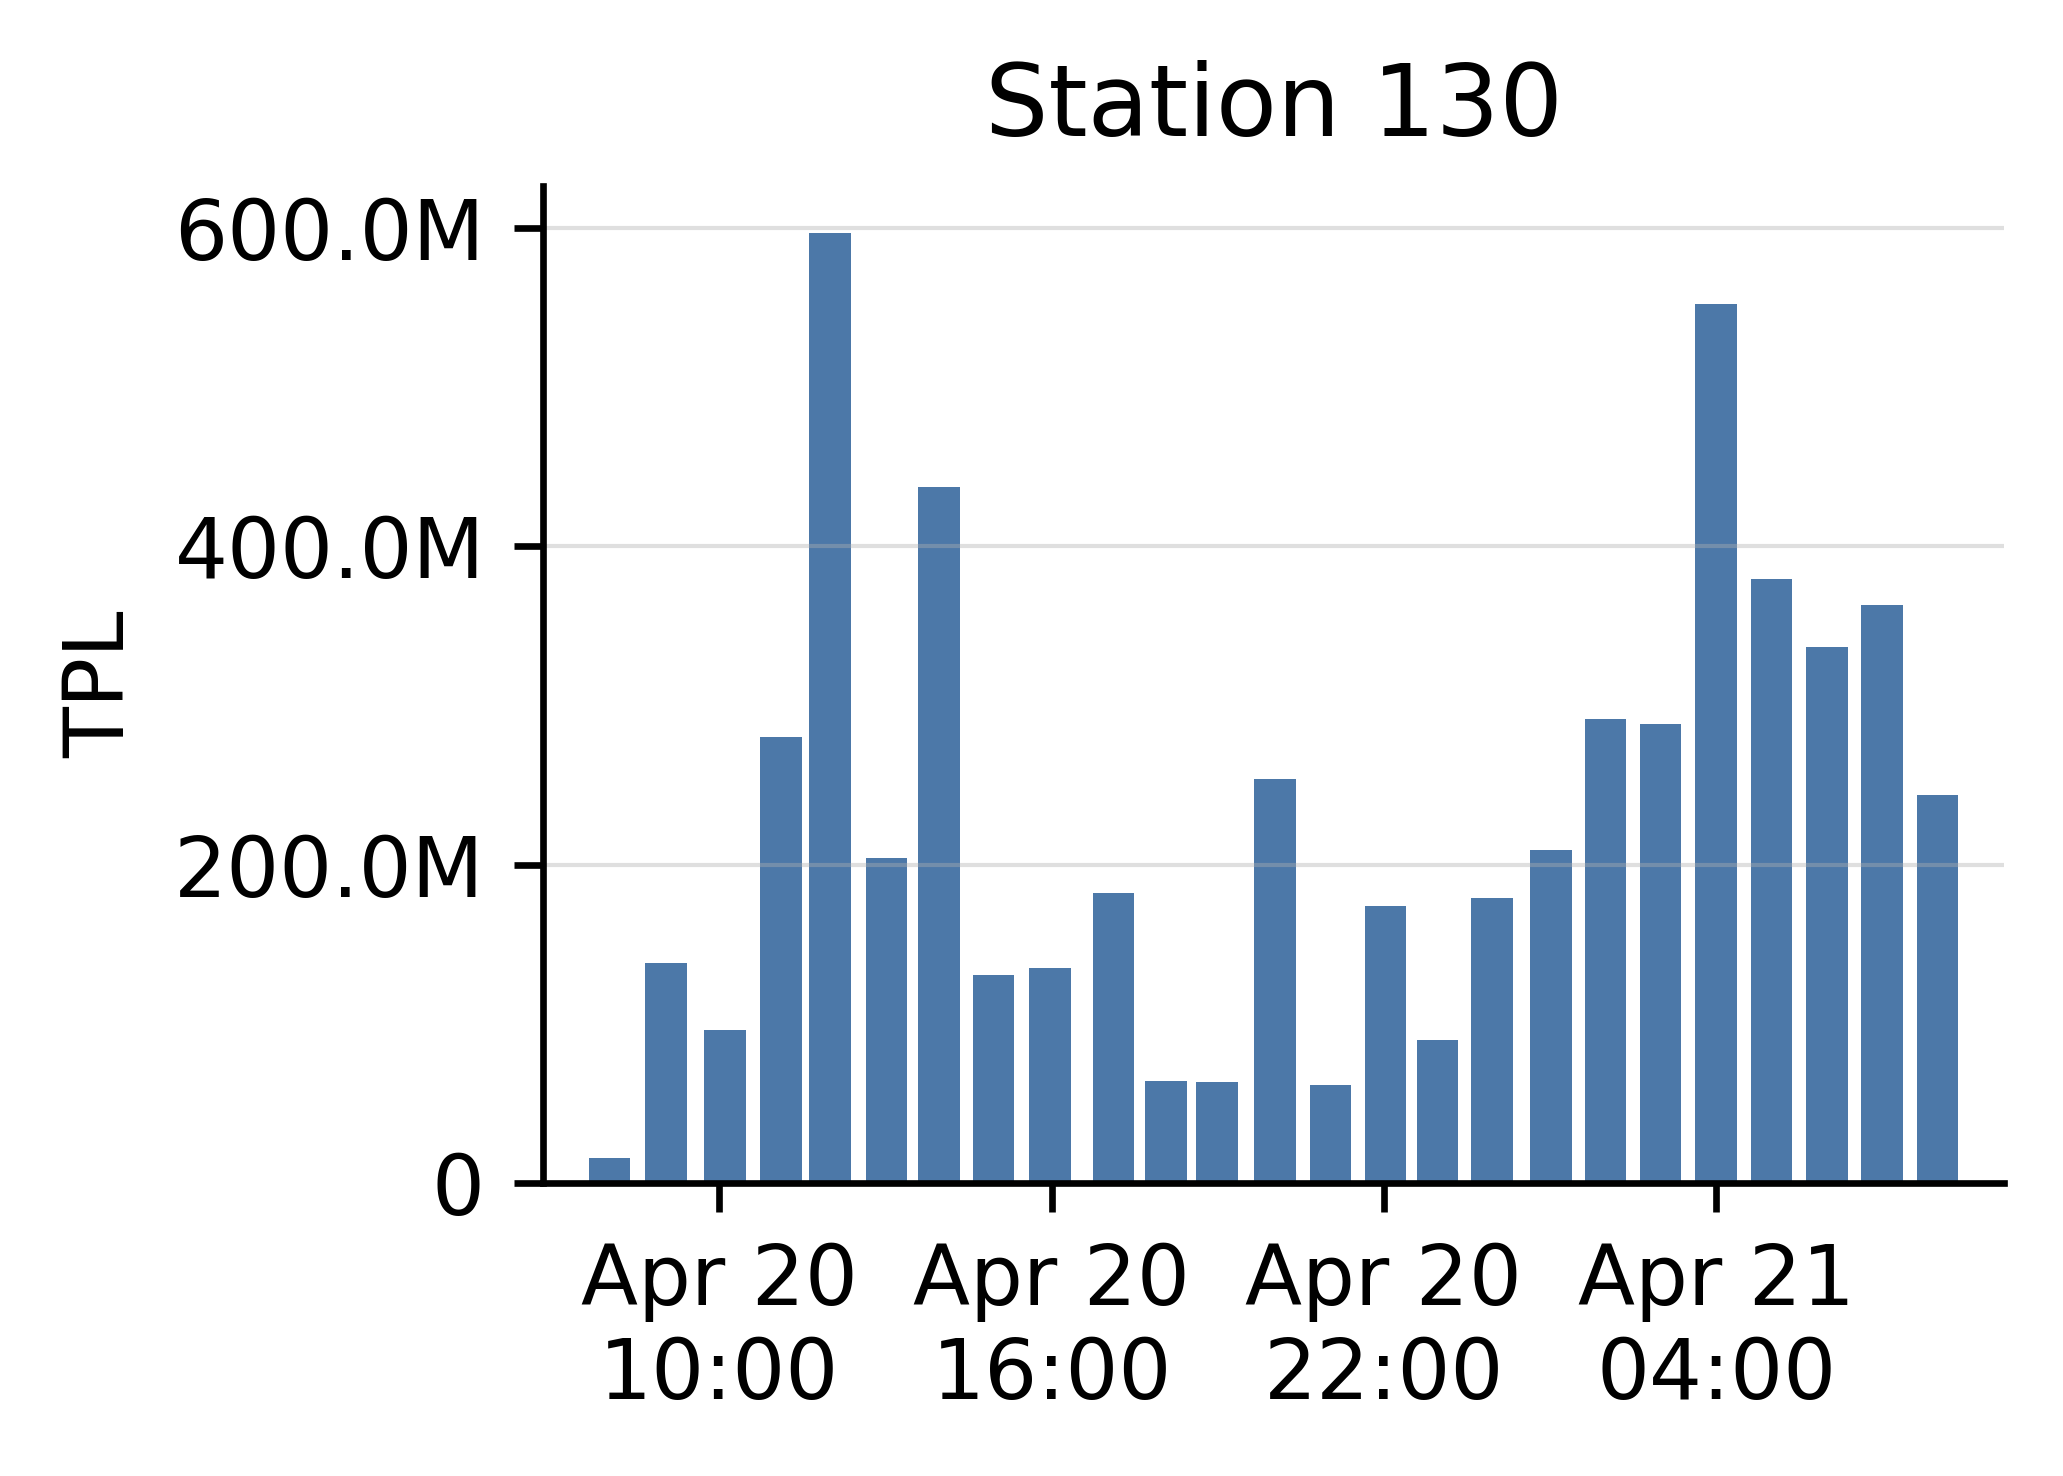

In [100]:
df = phaeo_numread_sums.copy()
df["Date"] = pd.to_datetime(df["Date"])

def fmt_y(x, pos):
    if x >= 1e6: return f"{x/1e6:.1f}M"
    if x >= 1e3: return f"{x/1e3:.0f}k"
    return f"{int(x)}"

# --- compute global y-limit across both stations ---
ymax = df["numreads"].max()
ymin = 0  # counts, so start at 0
ylims = (ymin, ymax * 1.05)  # small padding

def plot_station(sdf, station, outpath, expression_metric, ylims):
    sdf = sdf.query("StationPrefix == @station").sort_values("Date")
    if sdf.empty:
        print(f"No rows for station {station}")
        return

    fig, ax = plt.subplots(figsize=(3.54, 2.56), dpi=600)

    # Compute a sensible bar width from typical sampling interval
    xnum = date2num(sdf["Date"])
    if len(xnum) > 1:
        md = np.median(np.diff(xnum))
        width = md * 0.75
    else:
        width = (1/24) * 0.75  # ~45 min if single point

    ax.bar(xnum, sdf[expression_metric].to_numpy(), width=width, color="#4C78A8")

    # Titles/labels
    ax.set_title(f"Station {station}", pad=6)
    ax.set_ylabel(expression_metric)
    ax.set_xlabel("")

    # Y axis formatting + global limit
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_y))
    ax.set_ylim(ylims)

    # X ticks every 6 hours
    ax.xaxis.set_major_locator(HourLocator(interval=6))
    ax.xaxis.set_major_formatter(DateFormatter("%b %d\n%H:%M"))

    # Tighten to station-specific window with small padding
    pad = (xnum.max() - xnum.min()) * 0.05 if len(xnum) > 1 else (1/24)
    ax.set_xlim(xnum.min() - pad, xnum.max() + pad)

    # Grid & aesthetics
    ax.grid(True, axis="y", linewidth=0.5, alpha=0.4)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(outpath, dpi=600, bbox_inches="tight")
    plt.show()

# Generate both figures
plot_station(df, 51,  "../figures/metatranscriptomics/genome_resolved/numreads_station_51.png", "numreads", ylims)
plot_station(df, 130, "../figures/metatranscriptomics/genome_resolved/numreads_station_130.png","numreads",  ylims)

# Combine TPL per sample
df = transcripts_per_liter.sum(axis=0).reset_index()

# Name columns
df.columns = ['sample', 'TPL']

# Add environmental data to TPL sums
df = df.merge(env_data, on='sample', how='left')

# Update ymax and ylims for TPL
ymax = df["TPL"].max()
ylims = (0, ymax * 1.05)  # small padding

plot_station(df, 51,  "../figures/metatranscriptomics/genome_resolved/TPL_station_51.png", "TPL", ylims)
plot_station(df, 130, "../figures/metatranscriptomics/genome_resolved/TPL_station_130.png","TPL",  ylims)

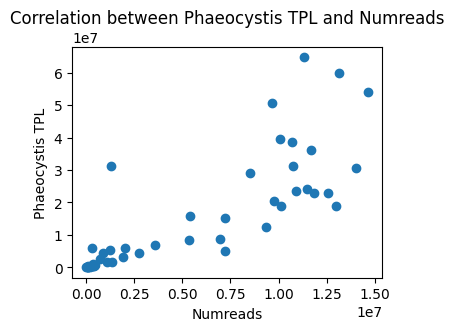

In [ ]:
# Check the correlation between phaeocystis TPL values extracted from the metatranscriptome and numreads
phaeo_tpl_130 = pd.read_csv('../data/analysis/phaeocystis_bin_tpl_130.csv')
phaeo_tpl_51 = pd.read_csv('../data/analysis/phaeocystis_bin_tpl_51.csv')

# Combine the dataframes for the two stations
phaeo_tpl = pd.concat([phaeo_tpl_51, phaeo_tpl_130], axis=0)

# Plot the correlation between phaeocystis TPL values and numreads
df = phaeo_numread_sums.copy()
df["Date"] = pd.to_datetime(df["Date"])

df = pd.merge(phaeo_tpl, df, on=["sample"])

plt.figure(figsize=(4,3))
plt.scatter(df['numreads'], df['TPL'])
plt.title('Correlation between Phaeocystis TPL and Numreads')
plt.xlabel('Numreads')
plt.ylabel('Phaeocystis TPL')
plt.show()

In [102]:
df.head()

,sample,TPL,numreads,StationPrefix,StationSuffix,Latitude,Longitude,Date,day_moment,day_length,...,Fluorescence,NH4,NO2,NO3,NOX,PO4,Si,TEP,sea_surface_height_above_sea_level,surface_baroclinic_sea_water_velocity
0,51_1,4.264275e+06,2762112.991,51,1,51.531661,3.182804,2023-04-18 11:11:00,Day,14.033333,...,2.001848,3.08,0.16,6.96,7.12,0.10,7.24,65.846667,1.817039,0.737313
1,51_10,4.403846e+06,881251.000,51,10,51.531665,3.182699,2023-04-18 20:05:00,Nautical twilight,14.033333,...,1.868159,4.31,0.17,7.27,7.44,0.13,7.21,212.590667,-0.643491,0.946217
2,51_11,3.859813e+05,311708.003,51,11,51.531646,3.182801,2023-04-18 21:07:00,Night,14.033333,...,1.546893,4.64,0.18,7.22,7.40,0.13,7.40,144.862667,-0.233241,0.725149
3,51_12,1.524327e+06,1054143.999,51,12,51.531677,3.182750,2023-04-18 22:02:00,Night,14.033333,...,2.431809,3.91,0.16,6.79,6.95,0.11,7.11,278.437333,0.313989,0.422929
4,51_13,7.633072e+05,461599.002,51,13,51.532296,3.184006,2023-04-18 23:11:00,Night,14.033333,...,2.767250,3.64,0.15,6.00,6.15,0.09,6.46,340.521333,1.264855,0.485325


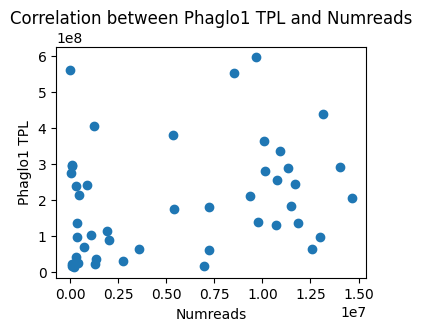

In [103]:
# Check the correlation between phaeocystis TPL values and genome-resolved TPL values
genome_tpl = transcripts_per_liter.sum(axis=0).reset_index()
# Rename columns
genome_tpl.columns = ['sample', 'TPL_genome']

# Merge with phaeo_tpl
df = df.merge(genome_tpl, on=["sample"])

plt.figure(figsize=(4,3))
plt.scatter(df['numreads'], df['TPL_genome'])
plt.title('Correlation between Phaglo1 TPL and Numreads')
plt.xlabel('Numreads')
plt.ylabel('Phaglo1 TPL')
plt.show()

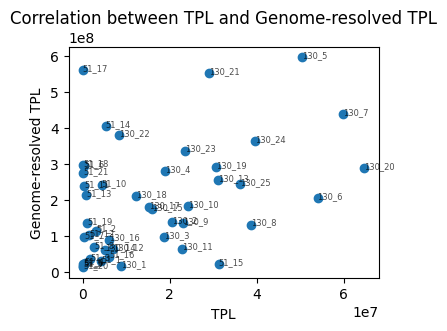

In [104]:
plt.figure(figsize=(4,3))
plt.scatter(df['TPL'], df['TPL_genome'])
plt.title('Correlation between TPL and Genome-resolved TPL')
plt.xlabel('TPL')
# Add sample labels to the points to identify potential outliers
for i, row in df.iterrows():
    plt.text(row['TPL'], row['TPL_genome'], row['sample'], fontsize=6, alpha=0.7)
plt.ylabel('Genome-resolved TPL')
plt.show()

In [ ]:
# Save transcripts per liter data calculated from the phaglo1 mapping
transcripts_per_liter.to_csv('../data/annotation/phaglo1_mapping/gene_expression/transcripts_per_liter.tsv', sep='\t')

# Export Data

In [117]:
def make_long_expression_table(expr_df, env_data, outfile, value_col="TPM"):
    """
    Create long-format expression table for Phaglo1_analysis.R
    
    Parameters
    ----------
    expr_df : pd.DataFrame
        Gene expression dataframe (rows=genes, cols=samples), TPM.
    env_data : pd.DataFrame
        Environmental metadata with columns ['sample', 'Date']
    outfile : str
        Path to save the resulting long-format CSV
    value_col : str
        Label for expression column in the output (TPM).
    """
    # Reset index to keep gene_id as a column
    expr_long = expr_df.reset_index().melt(
        id_vars="gene_id", var_name="sample", value_name="expression"
    )
    
    # Add station info
    expr_long["Station"] = expr_long["sample"].str.extract(r"^(51|130)")
    
    # Merge with env metadata
    expr_long = expr_long.merge(env_data, on="sample", how="left")
    
    # Derive time-of-day in hours
    expr_long["time_of_day_hours"] = expr_long["Date"].dt.hour + expr_long["Date"].dt.minute/60.0
    
    # Rename expression column if needed
    expr_long = expr_long.rename(columns={"expression": value_col})
    
    # Save
    expr_long.to_csv(outfile, index=False)
    print(f"Saved long table to {outfile} with {len(expr_long)} rows.")
    return expr_long

In [118]:
phaeo_tpm = pd.read_csv("../data/phaglo1_mapping/gene_expression/gene_tpm.tsv", sep="\t", index_col=0)
env_data = pd.read_csv("../data/samples_env.csv")
env_data["Date"] = pd.to_datetime(env_data["Date"])
env_data.rename(columns={"Station":"sample"}, inplace=True)

long_tpm = make_long_expression_table(phaeo_tpm, env_data,
                                      outfile="../data/phaglo1_mapping/gene_expression/phaeo_long_tpm.csv",
                                      value_col="TPM")

Saved long table to ../data/phaglo1_mapping/gene_expression/phaeo_long_tpm.csv with 1478394 rows.
